In [306]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Import packages for data preprocessing
from sklearn.feature_extraction.text import CountVectorizer

# Import packages for data modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, \
recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

In [50]:
df = pd.read_csv('tiktok_dataset.csv')
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [56]:
df.shape

(19382, 12)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [72]:
df.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [62]:
df.isna().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [70]:
df.duplicated().sum()

0

In [141]:
# drop rows that have missing values 
df = df.dropna(axis=0).copy()

In [80]:
df.isna().sum()

#                           0
claim_status                0
video_id                    0
video_duration_sec          0
video_transcription_text    0
verified_status             0
author_ban_status           0
video_view_count            0
video_like_count            0
video_share_count           0
video_download_count        0
video_comment_count         0
dtype: int64

In [82]:
# check the class distribution to see if there is a class imbalance problem
df['claim_status'].value_counts(normalize=True)

claim_status
claim      0.503458
opinion    0.496542
Name: proportion, dtype: float64

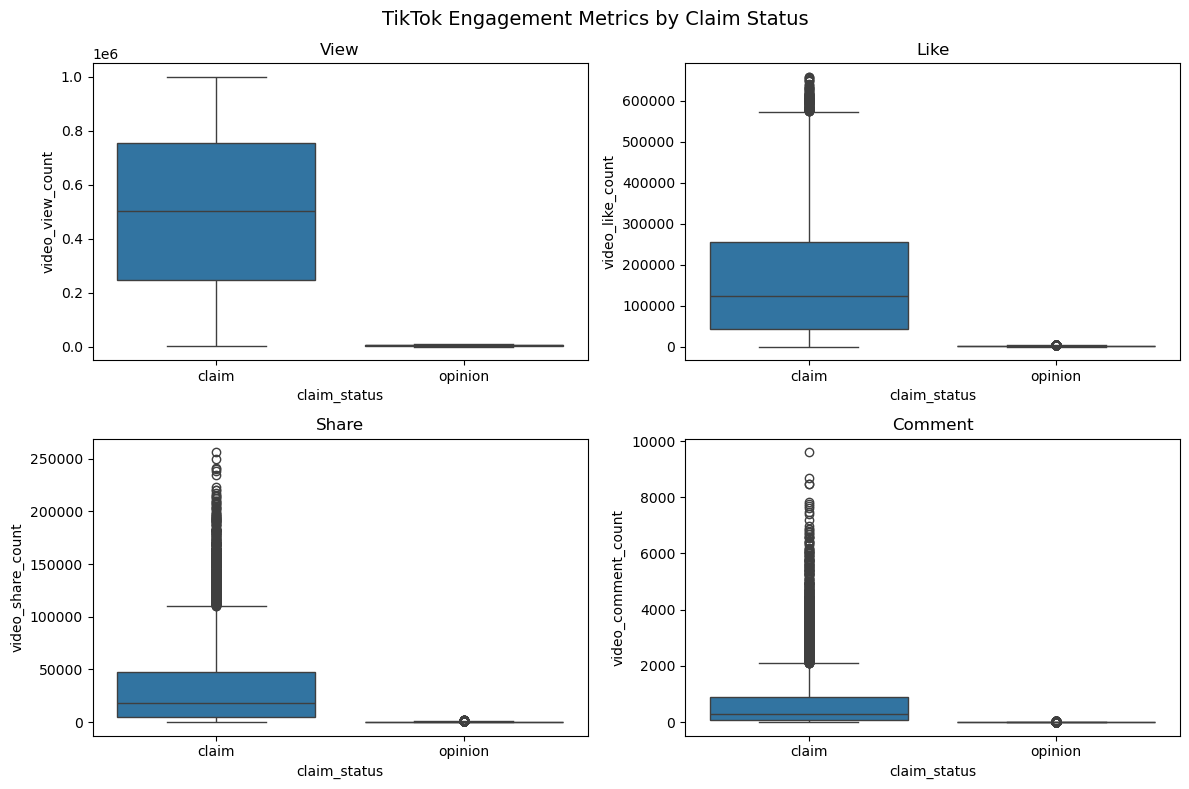

In [135]:
# check the distribution of 'engagement variables'
metrics = ['video_view_count', 'video_like_count', 
           'video_share_count', 'video_comment_count']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(metrics):
    sns.boxplot(x='claim_status', y=col, data=df, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(col.replace('video_', '').replace('_count', '').title())

plt.suptitle('TikTok Engagement Metrics by Claim Status', fontsize=14)
plt.tight_layout()
plt.show()

In [108]:
print(df['author_ban_status'].value_counts())

author_ban_status
active          15383
under review     2066
banned           1635
Name: count, dtype: int64

In [110]:
df['verified_status'].value_counts()

verified_status
not verified    17884
verified         1200
Name: count, dtype: int64

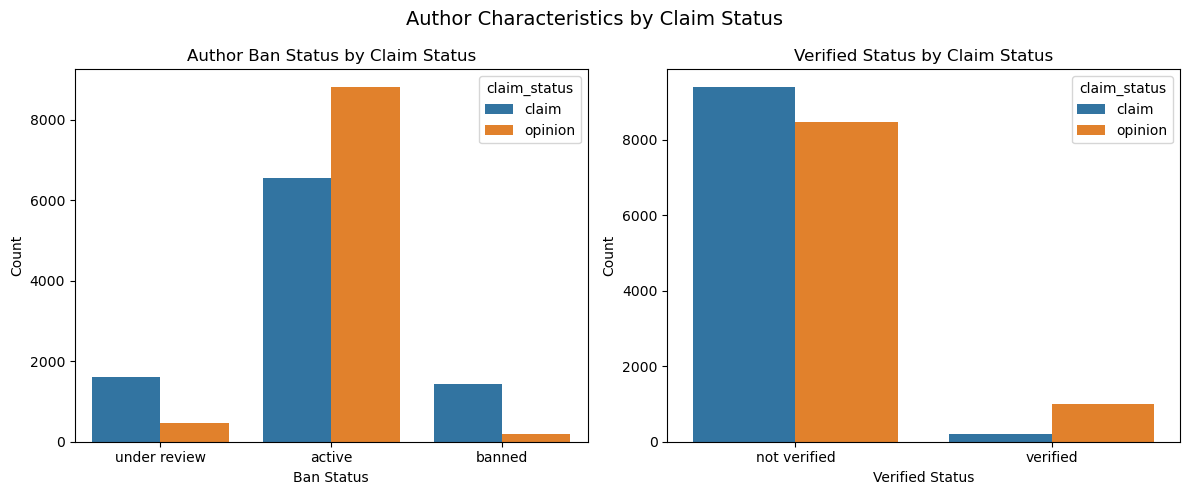

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# author_ban_status vs claim_status
sns.countplot(x='author_ban_status', hue='claim_status', data=df, ax=axes[0])
axes[0].set_title('Author Ban Status by Claim Status')
axes[0].set_xlabel('Ban Status')
axes[0].set_ylabel('Count')

# verified_status vs claim_status
sns.countplot(x='verified_status', hue='claim_status', data=df, ax=axes[1])
axes[1].set_title('Verified Status by Claim Status')
axes[1].set_xlabel('Verified Status')
axes[1].set_ylabel('Count')

plt.suptitle('Author Characteristics by Claim Status', fontsize=14)
plt.tight_layout()
plt.show()

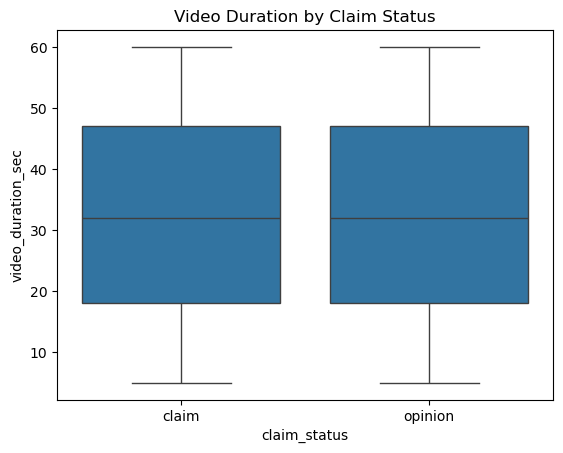

In [121]:
# check the relationship between video duration and claim status
sns.boxplot(x='claim_status', y='video_duration_sec', data=df)
plt.title('Video Duration by Claim Status')
plt.show()

In [145]:
df['text_length'] = df['video_transcription_text'].str.len()
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


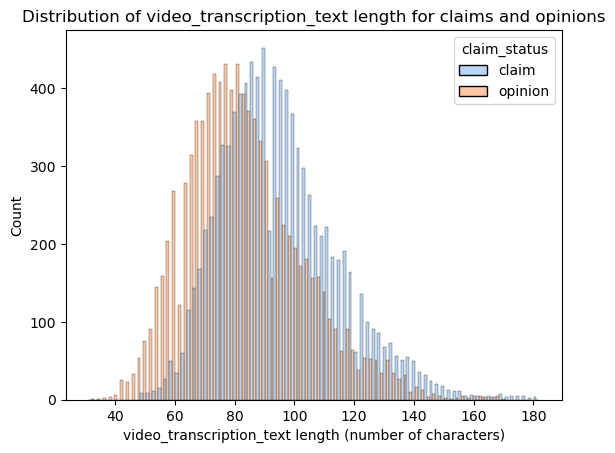

In [276]:
sns.histplot(data=df, stat="count", multiple="dodge", x="text_length",
             kde=False, palette="pastel", hue="claim_status",
             element="bars", legend=True)
plt.xlabel("video_transcription_text length (number of characters)")
plt.ylabel("Count")
plt.title("Distribution of video_transcription_text length for claims and opinions")
plt.show()

In [302]:
# Extract text for claim and opinion videos
claim_text = df[df['claim_status'] == 'claim']['video_transcription_text']
opinion_text = df[df['claim_status'] == 'opinion']['video_transcription_text']

# Fit CountVectorizer on claim text and get top 15 words
cv_claim = CountVectorizer(stop_words='english', max_features=15)
cv_claim.fit(claim_text)
claim_counts = cv_claim.transform(claim_text).toarray().sum(axis=0)
claim_words_df = pd.DataFrame({'word': cv_claim.get_feature_names_out(), 'count': claim_counts})
claim_words_df = claim_words_df.sort_values('count', ascending=False)

# Fit CountVectorizer on opinion text and get top 15 words
cv_opinion = CountVectorizer(stop_words='english', max_features=15)
cv_opinion.fit(opinion_text)
opinion_counts = cv_opinion.transform(opinion_text).toarray().sum(axis=0)
opinion_words_df = pd.DataFrame({'word': cv_opinion.get_feature_names_out(), 'count': opinion_counts})
opinion_words_df = opinion_words_df.sort_values('count', ascending=False)

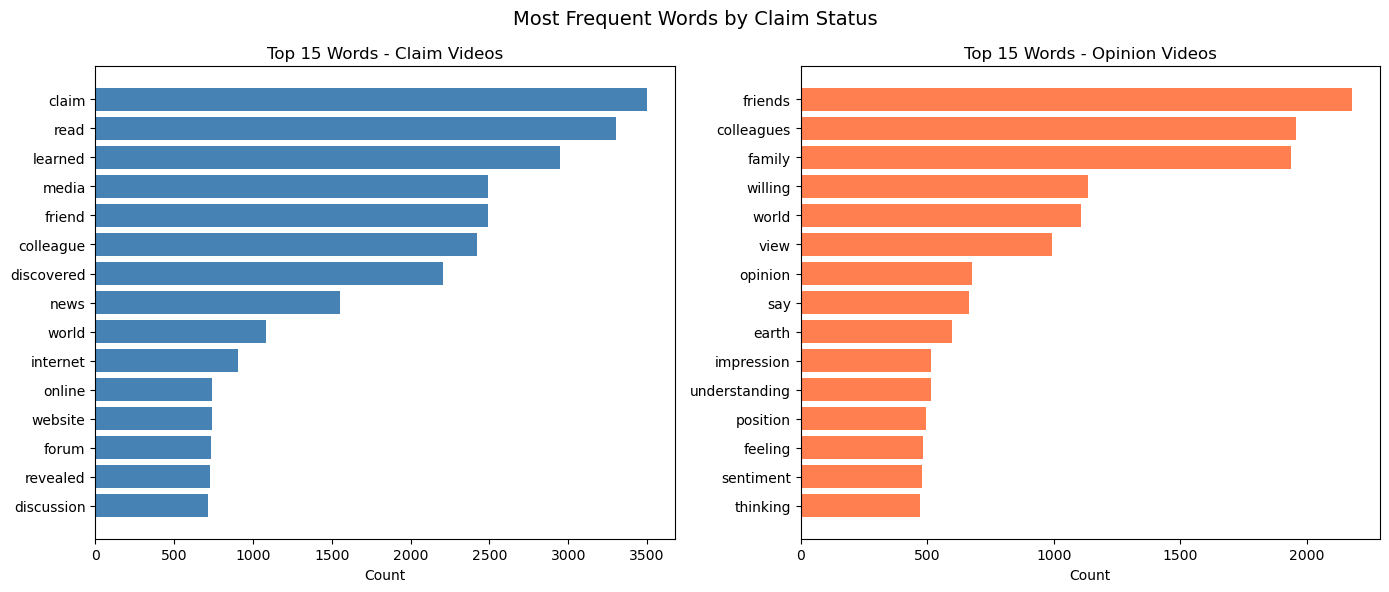

In [304]:
# Plot top 15 words for claim and opinion side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(claim_words_df['word'], claim_words_df['count'], color='steelblue')
axes[0].set_title('Top 15 Words - Claim Videos')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

axes[1].barh(opinion_words_df['word'], opinion_words_df['count'], color='coral')
axes[1].set_title('Top 15 Words - Opinion Videos')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.suptitle('Most Frequent Words by Claim Status', fontsize=14)
plt.tight_layout()
plt.show()

In [312]:
claim_views = df[df['claim_status'] == 'claim']['video_view_count']
opinion_views = df[df['claim_status'] == 'opinion']['video_view_count']

# Two-sample Welch t-test
t_stat, p_value = stats.ttest_ind(claim_views, opinion_views, equal_var=False)

print('T-statistic:', t_stat)
print('P-value:', p_value)

alpha = 0.05

if p_value < alpha:
    print('Result: There is a statistically significant difference in view counts between claim and opinion videos.')
else:
    print('Result: No statistically significant difference in view counts between claim and opinion videos.')

T-statistic: 166.88857822856752
P-value: 0.0
Result: There is a statistically significant difference in view counts between claim and opinion videos.


In [147]:
# claim=1, opinion=0
df['claim_status_encoded'] = df['claim_status'].map({'claim': 1, 'opinion': 0})

# verified=1, not verified=0
df['verified_status_encoded'] = df['verified_status'].map({'verified': 1, 'not verified': 0})

# active=0, under review=1, banned=2
df['author_ban_status_encoded'] = df['author_ban_status'].map({'active': 0, 'under review': 1, 'banned': 2})

In [151]:
df['engagement_rate'] = (df['video_like_count'] + df['video_comment_count'] + df['video_share_count']) / df['video_view_count']

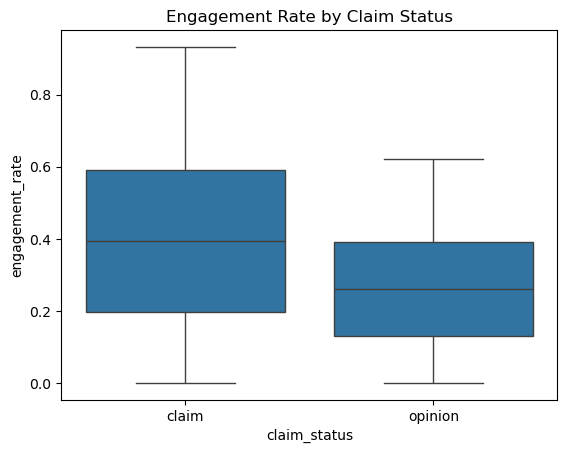

In [161]:
sns.boxplot(x='claim_status', y='engagement_rate', data=df)
plt.title('Engagement Rate by Claim Status')
plt.show()

In [153]:
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,claim_status_encoded,verified_status_encoded,author_ban_status_encoded,engagement_rate
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97,1,0,1,0.057286
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107,1,0,0,0.689062
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137,1,0,0,0.111814
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131,1,0,0,0.629363
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128,1,0,0,0.698791


In [165]:
# feature selection 
X = df.drop(columns=['claim_status', 'claim_status_encoded', 'video_id', 
                      'video_transcription_text', 'verified_status', 
                      'author_ban_status', '#'])

y = df['claim_status_encoded']

In [167]:
# split the test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# split the validation data
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0)

print('Train size:', X_train.shape)
print('Validation size:', X_val.shape)
print('Test size:', X_test.shape)

Train size: (11450, 10)
Validation size: (3817, 10)
Test size: (3817, 10)


In [175]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=0)

# Define hyperparameters to tune
cv_params = {'max_depth': [5, 7, None],
             'max_features': [0.3, 0.6],
             'max_samples': [0.7],
             'min_samples_leaf': [1, 2],
             'min_samples_split': [2, 3],
             'n_estimators': [75, 100, 200]}

# Define scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate GridSearchCV
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')

# Fit the model
rf_cv.fit(X_train, y_train)

# Check the best parameters and score
print('Best parameters:', rf_cv.best_params_)
print('Best recall score:', rf_cv.best_score_)

Best parameters: {'max_depth': 7, 'max_features': 0.6, 'max_samples': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 75}
Best recall score: 0.9917164013405635


In [177]:
%%time
rf_cv.fit(X_train, y_train)

CPU times: user 4min 18s, sys: 42.7 s, total: 5min
Wall time: 5min 55s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [5, 7, None], 'max_features': [0.3, 0.6],
                         'max_samples': [0.7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [75, 100, 200]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [183]:
# check the best recall score
rf_cv.best_score_

0.9917164013405635

In [181]:
# check the best parameters
rf_cv.best_params_

{'max_depth': 7,
 'max_features': 0.6,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 75}

In [192]:
# Convert GridSearch results to a dataframe
rf_results_df = pd.DataFrame(rf_cv.cv_results_)

# Check all scores at the best index
print('Precision:', rf_results_df['mean_test_precision'][rf_cv.best_index_])
print('Recall:   ', rf_results_df['mean_test_recall'][rf_cv.best_index_])
print('F1:       ', rf_results_df['mean_test_f1'][rf_cv.best_index_])
print('Accuracy: ', rf_results_df['mean_test_accuracy'][rf_cv.best_index_])

Precision: 0.9998251748251749
Recall:    0.9917164013405635
F1:        0.9957519010781436
Accuracy:  0.9957205240174671


In [212]:
# Get the best model
rf_best = rf_cv.best_estimator_
# Predict on validation set
y_pred_val = rf_best.predict(X_val)

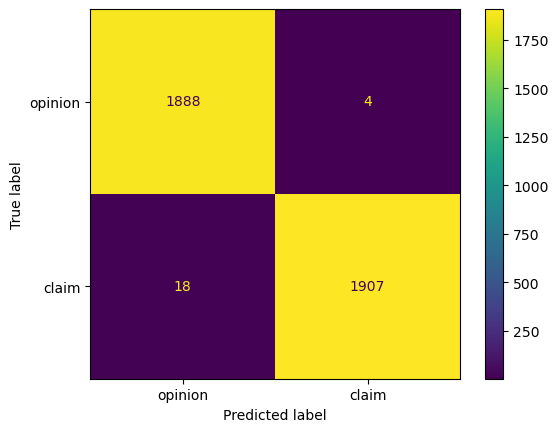

In [214]:
# Compute confusion matrix
rf_cm = confusion_matrix(y_val, y_pred_val)

# Display confusion matrix
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['opinion', 'claim'])
rf_disp.plot()
plt.show()

In [216]:
print(classification_report(y_val, y_pred_val, target_names=['opinion', 'claim']))

              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1892
       claim       1.00      0.99      0.99      1925

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



In [226]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# Define hyperparameters to tune
cv_params = {'max_depth': [4, 8, 12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [300, 500]}

# Define scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate GridSearchCV
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='recall')

In [228]:
%%time
xgb_cv.fit(X_train, y_train)

CPU times: user 40.1 s, sys: 1min 34s, total: 2min 14s
Wall time: 1min 16s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [4, 8, 12],
                         'min_child_weight': [3, 5],
                         'n_estimators': [300, 500]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [237]:
#check the best reall score
xgb_cv.best_score_

0.9901627422842335

In [239]:
#check the best parameter
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 4,
 'min_child_weight': 3,
 'n_estimators': 300}

In [243]:
# Get the best model
xgb_best = xgb_cv.best_estimator_
# Predict on validation set
y_pred_val_xgb = xgb_best.predict(X_val)

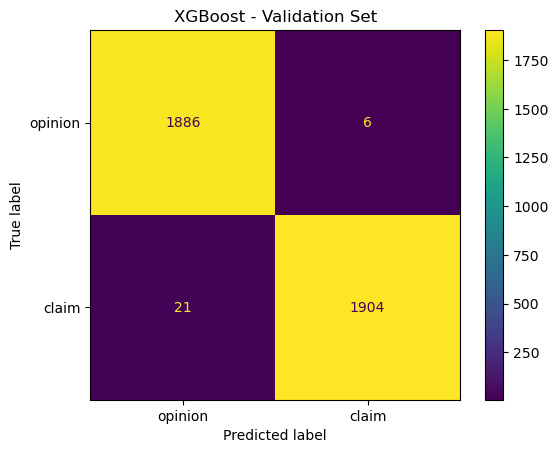

In [245]:
# Confusion matrix
xgb_cm = confusion_matrix(y_val, y_pred_val_xgb)
xgb_disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cm, display_labels=['opinion', 'claim'])
xgb_disp.plot()
plt.title('XGBoost - Validation Set')
plt.show()

In [247]:
# Classification report
print(classification_report(y_val, y_pred_val_xgb, target_names=['opinion', 'claim']))

              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1892
       claim       1.00      0.99      0.99      1925

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



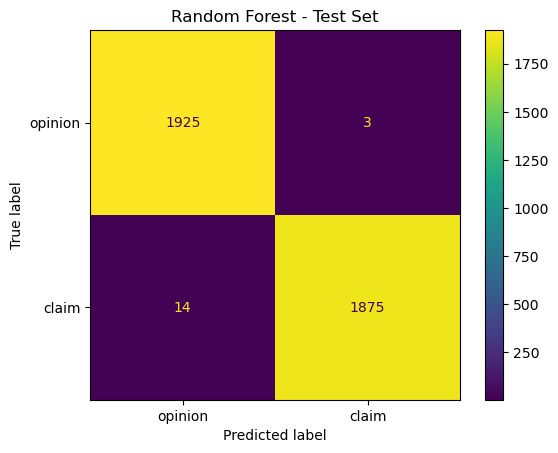

In [249]:
# Use champion model to predict on test data
y_pred_test = rf_cv.best_estimator_.predict(X_test)

# Compute confusion matrix
rf_cm_test = confusion_matrix(y_test, y_pred_test)

# Display confusion matrix
rf_disp_test = ConfusionMatrixDisplay(confusion_matrix=rf_cm_test, display_labels=['opinion', 'claim'])
rf_disp_test.plot()
plt.title('Random Forest - Test Set')
plt.show()

In [255]:
print(classification_report(y_test, y_pred_test, target_names=['opinion', 'claim']))

              precision    recall  f1-score   support

     opinion       0.99      1.00      1.00      1928
       claim       1.00      0.99      1.00      1889

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



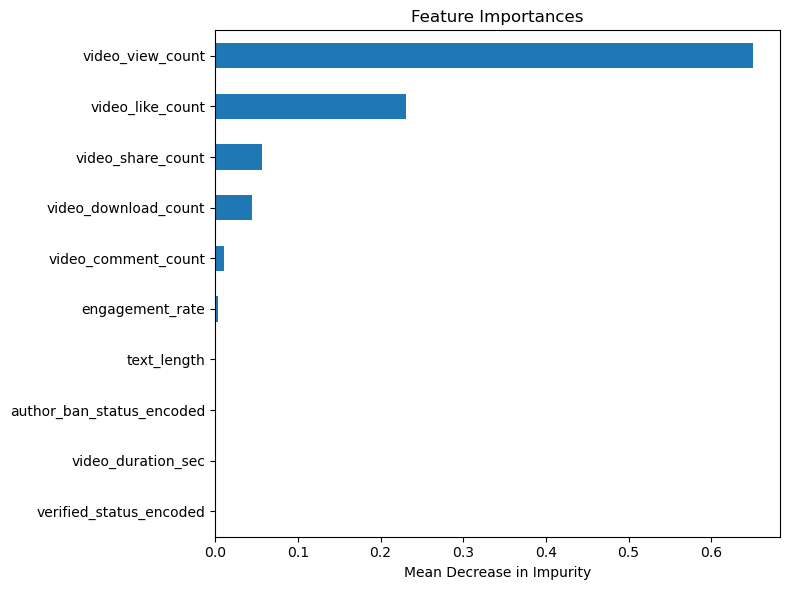

In [261]:
# Get feature importances
importances = rf_cv.best_estimator_.feature_importances_
rf_importances = pd.Series(importances, index=X.columns)

# Sort and plot
rf_importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importances')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()